# SVD in the Wild: PCA via Singular Value Decomposition

*Mathematical Foundations of Data Science (COMS4055A / COMS7058A)*

Group members:

| Name | Student number | Course code |
|---|---|---|
| Qiqa Bambeni | 1443727 | COMS7058A (Masters) |
| Fortune Mnisi | 1903697 | COMS4055A (Honours) |

This notebook derives Principal Component Analysis (PCA) from first principles via the Singular
Value Decomposition (SVD) and implements it directly, applies it to high-dimensional
spatiotemporal video data (Moving MNIST), reuses the identical implementation on a structurally
different domain (gridded sea-surface temperature, an EOF analysis), and critically evaluates the
limitations of linear projections on nonlinear data manifolds.

## 1. Introduction

Dimensionality reduction makes high-dimensional data tractable. This project builds PCA from first
principles via the SVD and applies it to two datasets. The primary task is Moving MNIST, a video
dataset of digits translating and bouncing inside a frame, where the underlying structure is
nonlinear. The secondary task is a gridded sea-surface-temperature (SST) field, where the
variability is well described by a few fixed spatial patterns. Comparing the singular-value spectra
and reconstructions of the two datasets illustrates when PCA performs well and where its limitations
appear.

## 2. Theory: Orthogonal Projection and Reconstruction Error

This section derives, in the notation of the course (Cleghorn, *Matrix Decompositions*, decks MD1 to MD3; Deisenroth, Faisal and Ong, *Mathematics for Machine Learning*, Chapter 10, the recommended text), the exact algebraic relationship between the orthogonal projection matrix and the minimisation of reconstruction error, and shows that the optimal subspace is spanned by the leading singular vectors of the data matrix.

*Convention (matching the lecture notes and MFML §10.1).* Data points are the columns of the data matrix, so $X=[\boldsymbol x_1,\dots,\boldsymbol x_N]\in\mathbb{R}^{D\times N}$ and the per-sample relations read left-to-right, $\tilde{\boldsymbol x}=BB^\top\boldsymbol x$ (MFML Remark, p. 323; eq. 10.34). The subspace dimension is $M$. The NumPy class in §3 instead stores the transposed, row-as-sample design matrix $A=X^\top\in\mathbb{R}^{N\times D}$ that `numpy.linalg.svd` expects; subsection 7 maps every symbol between the two layouts, so that the proof and the code describe one object in two coordinate systems.

| symbol | meaning |
|---|---|
| $N,\;D,\;M$ | samples, feature dimension, principal-subspace dimension $(M<D)$ |
| $X=[\boldsymbol x_1,\dots,\boldsymbol x_N]\in\mathbb{R}^{D\times N}$ | mean-centred data, samples in columns |
| $S=\tfrac1N XX^\top\in\mathbb{R}^{D\times D}$ | data covariance matrix (MFML eq. 10.1, 10.45) |
| $(\lambda_j,\boldsymbol u_j)$ | eigenpairs of $S$, $\lambda_1\ge\cdots\ge\lambda_D\ge0$ |
| $B=[\boldsymbol b_1,\dots,\boldsymbol b_M]\in\mathbb{R}^{D\times M}$ | orthonormal basis of the principal subspace, $B^\top B=I_M$ (MFML eq. 10.3) |
| $\boldsymbol z_n=B^\top\boldsymbol x_n\in\mathbb{R}^{M}$ | code, or scores, of sample $n$ (MFML eq. 10.2) |
| $P=BB^\top\in\mathbb{R}^{D\times D}$ | orthogonal projector onto the subspace |
| $\tilde{\boldsymbol x}_n=BB^\top\boldsymbol x_n$ | reconstruction of $\boldsymbol x_n$ (MFML eq. 10.34) |
| $X=U\Sigma V^\top$ | thin SVD of $X$, with singular values $\sigma_j$ |

#### 0. Setup

Let the mean-centred data matrix be

$$
X=[\boldsymbol x_1,\dots,\boldsymbol x_N]\in\mathbb{R}^{D\times N},\qquad \sum_{n=1}^{N}\boldsymbol x_n=\boldsymbol 0 .
$$

Centring is assumed throughout (MFML §10.2, "Centered Data" remark), so that every variance below is taken about the origin. The empirical data covariance is

$$
S=\frac1N\sum_{n=1}^N \boldsymbol x_n\boldsymbol x_n^\top=\frac1N XX^\top\in\mathbb{R}^{D\times D},
$$

symmetric positive semidefinite, with eigenpairs $(\lambda_j,\boldsymbol u_j)$ satisfying $\boldsymbol u_i^\top\boldsymbol u_j=\delta_{ij}$. We seek an $M$-dimensional subspace with orthonormal basis $B=[\boldsymbol b_1,\dots,\boldsymbol b_M]$, $B^\top B=I_M$.

#### 1. Optimal coordinates: the best linear reconstruction is the orthogonal projection

Reconstruct each sample linearly from its $M$ coordinates, $\tilde{\boldsymbol x}_n=B\boldsymbol z_n$. For a fixed basis $B$, the coordinates minimising the squared error of sample $n$ are

$$
\boldsymbol z_n^\star=\arg\min_{\boldsymbol z\in\mathbb{R}^{M}}\big\lVert\boldsymbol x_n-B\boldsymbol z\big\rVert_2^2 .
$$

Expanding the objective and using $B^\top B=I_M$,

$$
\big\lVert\boldsymbol x_n-B\boldsymbol z\big\rVert_2^2=\boldsymbol x_n^\top\boldsymbol x_n-2\,\boldsymbol z^\top B^\top\boldsymbol x_n+\boldsymbol z^\top\boldsymbol z .
$$

Setting the gradient with respect to $\boldsymbol z$ to zero,

$$
-2B^\top\boldsymbol x_n+2\boldsymbol z=\boldsymbol 0\;\;\Longrightarrow\;\;\boldsymbol z_n^\star=B^\top\boldsymbol x_n ,
$$

and the Hessian $2I_M\succ0$ confirms that the stationary point is the unique minimiser (MFML eq. 10.32). The optimal coordinates are therefore the orthogonal-projection coordinates, and the optimal reconstruction is

$$
\tilde{\boldsymbol x}_n=BB^\top\boldsymbol x_n=:P\boldsymbol x_n,\qquad P=BB^\top .
$$

This is precisely the orthogonal projection $\pi_{U}(\boldsymbol x_n)$ onto $U=\operatorname{span}(\boldsymbol b_1,\dots,\boldsymbol b_M)$ in the sense of the Gram-Schmidt projection operator of MD2 (MFML eq. 10.34). The matrix $P$ is an orthogonal projector, since it is symmetric, $P^\top=(BB^\top)^\top=BB^\top=P$, and idempotent, $P^2=B(B^\top B)B^\top=BB^\top=P$. Its eigenvalues therefore lie in $\{0,1\}$, and $I_D-P$ projects onto the orthogonal complement $U^\perp$.

#### 2. Reconstruction error equals the variance in the orthogonal complement

Define the per-sample average reconstruction error (MFML eq. 10.29):

$$
J_M=\frac1N\sum_{n=1}^N\big\lVert\boldsymbol x_n-\tilde{\boldsymbol x}_n\big\rVert_2^2 .
$$

Completing $B$ to a full orthonormal basis $(\boldsymbol b_1,\dots,\boldsymbol b_D)$ of $\mathbb{R}^D$, the displacement vector lies entirely in $U^\perp$ (MFML eq. 10.38):

$$
\boldsymbol x_n-\tilde{\boldsymbol x}_n=(I_D-P)\boldsymbol x_n=\sum_{j=M+1}^{D}(\boldsymbol b_j^\top\boldsymbol x_n)\,\boldsymbol b_j ,
$$

so that, by orthonormality of the $\boldsymbol b_j$,

$$
\big\lVert\boldsymbol x_n-\tilde{\boldsymbol x}_n\big\rVert_2^2=\sum_{j=M+1}^{D}(\boldsymbol b_j^\top\boldsymbol x_n)^2 .
$$

Averaging over $n$ and exchanging the order of summation (MFML eq. 10.43),

$$
J_M=\sum_{j=M+1}^{D}\boldsymbol b_j^\top\!\Big(\underbrace{\tfrac1N\sum_{n}\boldsymbol x_n\boldsymbol x_n^\top}_{=\,S}\Big)\boldsymbol b_j=\sum_{j=M+1}^{D}\boldsymbol b_j^\top S\,\boldsymbol b_j .
$$

Since $\sum_{j=1}^{D}\boldsymbol b_j^\top S\,\boldsymbol b_j=\operatorname{tr}(S)$ for any orthonormal basis, this is equivalently

$$
\boxed{\,J_M=\underbrace{\operatorname{tr}(S)}_{\text{total variance}}-\underbrace{\sum_{m=1}^{M}\boldsymbol b_m^\top S\,\boldsymbol b_m}_{\text{retained variance}}\,}.
$$

#### 3. Minimising reconstruction error is equivalent to maximising retained variance

The total variance,

$$
\operatorname{tr}(S)=\frac1N\lVert X\rVert_F^2=\sum_{j=1}^{D}\lambda_j ,
$$

is a fixed budget, independent of $B$. Consequently,

$$
\min_{B^\top B=I_M} J_M\quad\Longleftrightarrow\quad\max_{B^\top B=I_M}\ \sum_{m=1}^{M}\boldsymbol b_m^\top S\,\boldsymbol b_m .
$$

Every unit of variance the subspace captures is a unit of error it removes. Beginning from the projection, or reconstruction-error, perspective (MFML §10.3), we have arrived, with no further assumptions, at the maximum-variance perspective (MFML §10.2).

#### 4. The optimal basis via Lagrange multipliers

*First direction.* Maximise the projected variance of a unit vector (MFML eq. 10.10):

$$
\max_{\boldsymbol b_1}\ \boldsymbol b_1^\top S\,\boldsymbol b_1\quad\text{subject to}\quad\boldsymbol b_1^\top\boldsymbol b_1=1 .
$$

With Lagrangian $\mathcal L=\boldsymbol b_1^\top S\boldsymbol b_1+\lambda(1-\boldsymbol b_1^\top\boldsymbol b_1)$,

$$
\nabla_{\boldsymbol b_1}\mathcal L=2S\boldsymbol b_1-2\lambda\boldsymbol b_1=\boldsymbol 0\;\;\Longrightarrow\;\;S\boldsymbol b_1=\lambda\boldsymbol b_1
$$

(MFML eq. 10.13), so that $\boldsymbol b_1$ is an eigenvector of $S$, at which the objective equals $\boldsymbol b_1^\top S\boldsymbol b_1=\lambda$. To maximise it we take the largest eigenvalue, giving $\boldsymbol b_1=\boldsymbol u_1$ with value $\lambda_1$ (MFML eq. 10.15).

*Remaining directions.* For the $m$-th axis we maximise $\boldsymbol b^\top S\boldsymbol b$ subject to $\lVert\boldsymbol b\rVert=1$ and $\boldsymbol b\perp\boldsymbol u_1,\dots,\boldsymbol u_{m-1}$. The same stationarity condition, restricted to the orthogonal complement of the eigenvectors already chosen, returns $S\boldsymbol b=\lambda\boldsymbol b$ with the largest remaining eigenvalue, that is $\boldsymbol b=\boldsymbol u_m$ (MFML §10.2.2). By induction the optimal basis is the $M$ leading eigenvectors of $S$:

$$
B^\star=[\boldsymbol u_1,\dots,\boldsymbol u_M]=:U_M .
$$

Equivalently, in the compact (Ky Fan) form, $\max_{B^\top B=I_M}\operatorname{tr}(B^\top S B)=\sum_{m=1}^{M}\lambda_m$, attained at $U_M$. The minimal reconstruction error is then

$$
\boxed{\,J_M^\star=\sum_{j=1}^{D}\lambda_j-\sum_{m=1}^{M}\lambda_m=\sum_{j=M+1}^{D}\lambda_j\,}
$$

(MFML eq. 10.44): the sum of the discarded eigenvalues, that is, the variance held in $U^\perp$ which a rank-$M$ subspace cannot represent.

#### 5. Connection to PCA via the SVD

Take the thin SVD of the data matrix (MFML eq. 10.47; Cleghorn MD3, SVD Theorem):

$$
X=U\Sigma V^\top,\quad U\in\mathbb{R}^{D\times r},\ \Sigma=\operatorname{diag}(\sigma_1,\dots,\sigma_r),\ V\in\mathbb{R}^{N\times r},
$$

with $r=\operatorname{rank}(X)$, $U^\top U=V^\top V=I_r$, and $\sigma_1\ge\cdots\ge\sigma_r\ge0$. Then, using $V^\top V=I_r$,

$$
S=\frac1N XX^\top=\frac1N U\Sigma V^\top V\Sigma U^\top=U\Big(\tfrac1N\Sigma^2\Big)U^\top ,
$$

which is exactly the eigendecomposition of $S$ (MFML eq. 10.48). For a symmetric positive semidefinite matrix the SVD and the eigendecomposition coincide (Cleghorn MD3), so the eigenvectors of the covariance are the left singular vectors of $X$, with

$$
\lambda_j=\frac{\sigma_j^2}{N}
$$

(MFML eq. 10.49; Cleghorn MD3, $\sigma_i^2=\lambda_i$ for the associated Gram matrix). Combining this with §4, the optimal basis is the leading left singular vectors, $B^\star=U_M$. The scores and the reconstruction are

$$
Z=B^{\star\top}X=U_M^\top U\Sigma V^\top=\Sigma_M V_M^\top,\qquad
\tilde X=U_M U_M^\top X=U_M\Sigma_M V_M^\top ,
$$

that is, the rank-$M$ truncated SVD of $X$ (Cleghorn MD3, eq. (40), $\hat A(k)=\sum_{i=1}^{k}\sigma_i\boldsymbol u_i\boldsymbol v_i^\top$; MFML eq. 10.51). By the Eckart-Young theorem this is the best rank-$M$ approximation of $X$ (MFML Thm. 4.25). In the Frobenius norm relevant to PCA,

$$
\big\lVert X-\tilde X\big\rVert_F^2=\sum_{j=M+1}^{r}\sigma_j^2\ \Longrightarrow\ J_M^\star=\frac1N\sum_{j=M+1}^{r}\sigma_j^2=\sum_{j=M+1}^{D}\lambda_j ,
$$

in exact agreement with §4. The minimum-reconstruction-error projection and the truncated SVD are therefore the same object, reached from two independent directions.

#### 6. One solution, two perspectives

We began from reconstruction error and, using only the fact that the total variance is fixed, reduced it to maximum variance. Both are solved by the leading eigenvectors of $S$, equivalently the leading left singular vectors of $X$, and the SVD of §5 is what makes the two coincide.

$$
X\in\mathbb{R}^{D\times N},\quad B=U_M\in\mathbb{R}^{D\times M},\quad P=BB^\top\in\mathbb{R}^{D\times D},\quad Z=B^\top X\in\mathbb{R}^{M\times N},\quad \tilde X=PX\in\mathbb{R}^{D\times N}.
$$

#### 7. Bridge to the implementation (row-as-sample layout)

The class in §3 works with the transpose $A=X^\top\in\mathbb{R}^{N\times D}$, placing samples in rows, which is the layout `numpy.linalg.svd` expects. Since $A=X^\top=V\Sigma U^\top$, the SVD of $A$ has left singular vectors $V$ and right singular vectors equal to the columns of $U$. The implementation therefore stores

$$
\texttt{components\_}=U^\top\ \ (\text{rows are }\boldsymbol u_1,\dots),\qquad
\texttt{singular\_values\_}=(\sigma_j),\qquad
\texttt{explained\_variance\_}=\Big(\tfrac{\sigma_j^2}{N}\Big)=(\lambda_j).
$$

Hence `components_[:k]` holds the principal axes $\boldsymbol b_1,\dots,\boldsymbol b_k$ row-wise; `transform` returns $A\,\texttt{components\_[:k]}^\top$, whose row $n$ is $\boldsymbol z_n^\top=(B^\top\boldsymbol x_n)^\top$; and `reconstruct` applies $A\mapsto A\,B B^\top$, the row-stacked form of $\tilde{\boldsymbol x}_n=BB^\top\boldsymbol x_n$. The projector is applied from the right only because the samples are rows; the subspace, the scores, and the error are identical to the column-convention derivation above.

The closed-form minimal error $J_M^\star=\sum_{j>M}\lambda_j=\tfrac1N\sum_{j>M}\sigma_j^2$ is the spectral expression returned by `theoretical_reconstruction_error`. In the mean-centred, unscaled case it agrees with the directly measured Frobenius error of the reconstructions to floating-point tolerance, an empirical confirmation of this derivation that is checked in the verification cells. Under optional standardisation the measured error is reported in original units and the two quantities differ, since the identity above lives in the standardised space.


## 3. A reusable PCA implementation from the SVD

The class below implements PCA using `numpy.linalg.svd` only; no automated PCA wrapper is used. It
follows the row-as-sample convention $X\in\mathbb{R}^{N\times D}$ and provides mean-centring,
optional standardisation, projection, reconstruction, the cumulative explained-variance ratio, and the
reconstruction error in both empirical and spectral forms. The full decomposition is stored on `fit`,
so any truncation level $k$ can be explored without refitting.

*Numerical stability.* For $D>N$ (the case for both datasets here) the class uses the $N\times N$
Gram-matrix solver, which is far cheaper in memory. To confirm this does not cost accuracy, the
verification cell below checks that the Gram solver returns the same singular values as the direct
SVD path (`svd_solver='full'`), and that the empirically measured reconstruction error equals the
spectral value $\sum_{j>k}\lambda_j$ on the real Moving MNIST data.

In [1]:
# Setup
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

USE_REAL_DATA = True    # set False to force the synthetic fallback
N_MNIST = 10000         # full dataset: the CEV curve is computed over all sequences (per the brief)

if USE_REAL_DATA:
    get_ipython().system('pip install -q xarray netcdf4')   # for reading NetCDF climate data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 168.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.8 MB/s eta 0:00:00


In [2]:
"""
PCA via the SVD, NumPy only (no sklearn).

Works on any 2-D array of shape (N, D) = (samples in rows, features in
columns), so the same object serves both the Moving MNIST and climate tasks.

For the centered data X_c the thin SVD is X_c = U @ diag(s) @ V^T, r = min(N, D):
    U   (N, r)   left singular vectors
    s   (r,)     singular values, s_1 >= ... >= s_r >= 0
    V^T (r, D)   right singular vectors = principal axes (stored as components_)

The right singular vectors are the eigenvectors of S = (1/N) X_c^T X_c, with
eigenvalues s_i^2 / N. S is never formed (O(D^2) memory, infeasible at D ~ 80k):
'full' decomposes X_c directly, while for D > N 'gram' eigendecomposes the
N x N matrix X_c X_c^T instead -- cheaper, but it squares the condition number
(see svd_solver).
"""

import numpy as np


class PCA:
    """PCA via the SVD.

    Parameters
    ----------
    n_components : int or None
        Default k to keep (None -> all r = min(N, D)). fit() stores the full
        decomposition, so any k <= r can be used afterwards without refitting.
    scale : bool
        True standardises each feature to unit variance (correlation PCA);
        False only centers (covariance PCA).
    svd_solver : {'auto', 'full', 'gram'}
        'full' : np.linalg.svd on the centered data.
        'gram' : eigendecompose X_c X_c^T (N x N); cheaper when D >> N, less precise.
        'auto' : 'gram' when D > N, else 'full'.
    dtype : numpy dtype
        Working precision (default float64). float32 roughly halves the memory
        for very large D*N at negligible cost to the explained-variance ratio.
    """

    def __init__(self, n_components=None, scale=False, svd_solver="auto", dtype=np.float64):
        self.n_components = n_components
        self.scale = scale
        self.svd_solver = svd_solver
        self.dtype = dtype

        # learned state (set by fit)
        self.mean_ = None
        self.scale_ = None
        self.components_ = None                 # (r, D) right singular vectors
        self.singular_values_ = None            # (r,)
        self.explained_variance_ = None         # (r,) s_i^2 / N
        self.explained_variance_ratio_ = None   # (r,)
        self.n_samples_ = None
        self.n_features_ = None
        self.n_components_ = None               # r = min(N, D)

    def fit(self, X):
        """Learn the principal axes from X (N, D). Returns self."""
        X = np.asarray(X, dtype=self.dtype)
        if X.ndim != 2:
            raise ValueError("X must be 2-D, shape (n_samples, n_features).")
        N, D = X.shape
        self.n_samples_, self.n_features_ = N, D

        # center (PCA is about variance around the mean)
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_

        # optional standardisation -> correlation- instead of covariance-PCA
        if self.scale:
            std = Xc.std(axis=0, ddof=0)
            std[std == 0.0] = 1.0               # guard constant features
            self.scale_ = std
            Xc = Xc / self.scale_
        else:
            self.scale_ = np.ones(D)

        solver = self.svd_solver
        if solver == "auto":
            solver = "gram" if D > N else "full"
        elif solver == "gram" and D <= N:
            solver = "full"                     # gram is only valid for D > N

        if solver == "full":
            U, s, Vt = self._svd_full(Xc)
        elif solver == "gram":
            U, s, Vt = self._svd_gram(Xc)
        else:
            raise ValueError(f"Unknown svd_solver: {self.svd_solver!r}")

        # SVD signs are arbitrary; fix them for run-to-run reproducibility
        U, Vt = self._svd_flip(U, Vt)

        r = s.shape[0]
        self.n_components_ = r
        # after centering rank <= N-1, so the last component is ~zero-variance
        self.singular_values_ = s
        self.components_ = Vt                    # (r, D) principal axes in rows
        self.explained_variance_ = (s ** 2) / N         # eigenvalues of S
        total_variance = self.explained_variance_.sum()
        self.explained_variance_ratio_ = (
            self.explained_variance_ / total_variance
        )
        return self

    @staticmethod
    def _svd_full(Xc):
        """Thin SVD of the centered data. Cost O(N * D * min(N, D))."""
        U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
        return U, s, Vt

    @staticmethod
    def _svd_gram(Xc):
        """SVD via the N x N Gram matrix, for D >> N.

        X_c X_c^T = U diag(s)^2 U^T, so eigendecomposing it gives U and s;
        the right singular vectors follow from V = X_c^T U diag(s)^{-1}.
        Cost O(N^2 D + N^3) vs O(N D^2). Forming the Gram matrix squares the
        condition number, so this trades precision for memory/speed.
        """
        N, D = Xc.shape
        G = Xc @ Xc.T
        eigvals, eigvecs = np.linalg.eigh(G)            # ascending order
        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        eigvals = np.clip(eigvals, 0.0, None)           # round-off can go negative
        s = np.sqrt(eigvals)
        U = eigvecs

        # recover V^T = (X_c^T U diag(s)^{-1})^T, skipping ~zero singular values
        tol = np.finfo(s.dtype).eps * max(N, D) * (s[0] if s.size else 1.0)
        nonzero = s > tol
        Vt = np.zeros((N, D), dtype=Xc.dtype)
        if np.any(nonzero):
            V_nz = (Xc.T @ U[:, nonzero]) / s[nonzero]
            Vt[nonzero] = V_nz.T
        return U, s, Vt

    @staticmethod
    def _svd_flip(U, Vt):
        """Sign each right singular vector by its largest-magnitude entry,
        flipping the matching left singular vector to match."""
        max_abs_cols = np.argmax(np.abs(Vt), axis=1)
        signs = np.sign(Vt[np.arange(Vt.shape[0]), max_abs_cols])
        signs[signs == 0] = 1.0
        Vt = Vt * signs[:, np.newaxis]
        if U is not None:
            U = U * signs[np.newaxis, :]
        return U, Vt

    def _resolve_k(self, k):
        """Validate k and apply the default."""
        if self.components_ is None:
            raise RuntimeError("Call fit() before transform/reconstruct.")
        if k is None:
            k = self.n_components if self.n_components is not None else self.n_components_
        if not (1 <= k <= self.n_components_):
            raise ValueError(f"k must be in [1, {self.n_components_}], got {k}.")
        return k

    def _preprocess(self, X):
        """Apply the stored centering and scaling (so unseen data is treated
        like the training data)."""
        X = np.asarray(X, dtype=self.dtype)
        return (X - self.mean_) / self.scale_

    def transform(self, X, k=None):
        """Project X (N, D) onto the top-k axes -> scores Z (N, k)."""
        k = self._resolve_k(k)
        Xc = self._preprocess(X)
        B = self.components_[:k].T                         # (D, k)
        return Xc @ B

    def fit_transform(self, X, k=None):
        """fit(), then return the projected scores."""
        self.fit(X)
        return self.transform(X, k)

    def inverse_transform(self, Z):
        """Map scores Z (N, k) back to the original feature space (N, D),
        reversing the scaling and centering."""
        Z = np.asarray(Z, dtype=self.dtype)
        k = Z.shape[1]
        if k > self.n_components_:
            raise ValueError("Z has more columns than available components.")
        B = self.components_[:k]                           # (k, D)
        Xc_hat = Z @ B
        return Xc_hat * self.scale_ + self.mean_

    def reconstruct(self, X, k=None):
        """Best rank-k linear approximation of X: project to k dims and map
        back. Returns (N, D)."""
        k = self._resolve_k(k)
        return self.inverse_transform(self.transform(X, k))

    def cumulative_explained_variance_ratio(self):
        """Running sum of explained_variance_ratio_ -> (r,)."""
        if self.explained_variance_ratio_ is None:
            raise RuntimeError("Call fit() first.")
        return np.cumsum(self.explained_variance_ratio_)

    def reconstruction_error(self, X, k=None):
        """Empirical MSE reconstruction error in the original space:
        J(k) = (1/N) sum_n || x_n - x_hat_n ||^2."""
        k = self._resolve_k(k)
        X = np.asarray(X, dtype=self.dtype)
        X_hat = self.reconstruct(X, k)
        diff = X - X_hat
        return np.mean(np.sum(diff ** 2, axis=1))

    def theoretical_reconstruction_error(self, k=None):
        """Reconstruction error from the spectrum: the discarded variance
        J(k) = sum_{i>k} explained_variance_[i].

        Measured in the preprocessed space, so it matches reconstruction_error()
        when scale=False; with scale=True the empirical error is in original
        units and the two differ (expected, not a bug).
        """
        k = self._resolve_k(k)
        return float(self.explained_variance_[k:].sum())

    def __repr__(self):
        if self.components_ is None:
            return f"PCA(n_components={self.n_components}, scale={self.scale}) [unfitted]"
        return (
            f"PCA(fitted: N={self.n_samples_}, D={self.n_features_}, "
            f"r={self.n_components_}, scale={self.scale})"
        )

In [3]:
# Quick correctness check on a small matrix
# Full-rank reconstruction is exact, and empirical error matches the spectral
# value sum_{j>k} lambda_j from the proof.
_r = np.random.default_rng(0)
_X = _r.normal(size=(200, 8)) @ _r.normal(size=(8, 8))
_p = PCA(scale=False).fit(_X)
assert np.allclose(_p.reconstruct(_X, k=8), _X), "full-rank reconstruction should be exact"
for _k in (1, 3, 5):
    emp = _p.reconstruction_error(_X, _k)
    spec = _p.theoretical_reconstruction_error(_k)
    print(f"k={_k}: empirical={emp:.4f}  spectral={spec:.4f}  match={np.isclose(emp, spec)}")

k=1: empirical=51.9328  spectral=51.9328  match=True
k=3: empirical=15.0115  spectral=15.0115  match=True
k=5: empirical=1.8144  spectral=1.8144  match=True


## 4. Primary application: Moving MNIST

*Reshape (one sequence is one data point).* Each video has shape $(F, H, W)$: $F$ ordered frames of $H\times W$ pixels. Following the structure of the dataset, we treat one whole sequence as a single data point and flatten it, in a fixed order, into one row of length $F\cdot H\cdot W$. The design matrix is therefore $X\in\mathbb{R}^{N\times FHW}$ (the theory's $N\times D$ matrix, with $D=FHW$), and the full dataset supplies $N=10{,}000$ such points. Because every sequence is flattened in the same fixed order, column $j$ always refers to the same $(\text{frame},\text{pixel})$ coordinate across all samples, so the temporal structure is preserved: a frame-$t$ feature and a frame-$(t{+}1)$ feature occur together in every row, and the cross-covariance that encodes how pixels evolve between frames is available to the SVD.

*Scope of the variance analysis.* The cumulative-explained-variance curve below is computed over the entire dataset of $10{,}000$ sequences, so it reflects the spectrum of the full sample rather than a subsample. Since $D=FHW=81{,}920$ greatly exceeds $N$, the $D\times D$ covariance is never formed; the class fits through the $N\times N$ Gram solver (§3), which reduces the decomposition to a $10{,}000\times 10{,}000$ eigenproblem. The fit remains memory-intensive at this size, so it is run in single precision, which the verification below shows leaves the explained-variance ratio unchanged to roughly six decimal places while approximately halving the footprint; a high-RAM runtime is nonetheless advisable.

*Note for the final run.* The exact 90% and 95% component counts, the per-component variance shares quoted in §7, and the spectral crossover shown in Figure 7 are data-dependent. Regenerate them from the full-dataset run and update the surrounding prose accordingly before submission.

In [4]:
# Moving MNIST: load real data (with synthetic fallback)
MNIST_URL = "https://www.cs.toronto.edu/~nitish/unsupervised_video/mnist_test_seq.npy"

def load_moving_mnist_real(n_seq):
    if not os.path.exists("mnist_test_seq.npy"):
        get_ipython().system('wget -q -T 30 -t 1 ' + MNIST_URL)
    arr = np.load("mnist_test_seq.npy")              # Toronto layout: (F, S, H, W)
    if arr.ndim == 4 and arr.shape[0] < arr.shape[1]:
        arr = np.transpose(arr, (1, 0, 2, 3))        # -> (S, F, H, W)
    return (arr[:n_seq].astype(np.float32) / 255.0)

def make_synthetic_moving_mnist(n_seq=240, n_frames=20, size=64, n_digits=2, seed=0):
    from sklearn.datasets import load_digits         # offline fallback only: supplies digit *images*, not sklearn's PCA wrapper (which the brief forbids and we never use)
    rng = np.random.default_rng(seed)
    raw = load_digits().images; raw = raw / raw.max()
    patch = np.kron(raw, np.ones((2, 2))); pH = patch.shape[1]; lim = size - pH
    T = np.zeros((n_seq, n_frames, size, size), np.float32)
    for s in range(n_seq):
        idx = rng.integers(0, len(patch), size=n_digits)
        pos = rng.uniform(0, lim, size=(n_digits, 2)); vel = rng.uniform(-4, 4, size=(n_digits, 2))
        for f in range(n_frames):
            fr = np.zeros((size, size), np.float32)
            for d in range(n_digits):
                yi, xi = int(round(pos[d, 0])), int(round(pos[d, 1]))
                fr[yi:yi+pH, xi:xi+pH] = np.maximum(fr[yi:yi+pH, xi:xi+pH], patch[idx[d]])
                pos[d] += vel[d]
                for c in range(2):
                    if pos[d, c] < 0:
                        pos[d, c] = -pos[d, c]
                        vel[d, c] *= -1
                    elif pos[d, c] > lim:
                        pos[d, c] = 2 * lim - pos[d, c]
                        vel[d, c] *= -1
            T[s, f] = fr
    return T

if USE_REAL_DATA:
    try:
        T_mnist = load_moving_mnist_real(N_MNIST)
        print("Loaded REAL Moving MNIST:", T_mnist.shape)
    except Exception as e:
        print("WARNING: real Moving MNIST unavailable (", repr(e), ") -> SYNTHETIC fallback")
        T_mnist = make_synthetic_moving_mnist(N_MNIST)
else:
    T_mnist = make_synthetic_moving_mnist(N_MNIST)
print("video tensor (S, F, H, W):", T_mnist.shape)

Loaded REAL Moving MNIST: (10000, 20, 64, 64)
video tensor (S, F, H, W): (10000, 20, 64, 64)


In [5]:
# Moving MNIST: reshape (sequence-as-sample) and fit
S, F, H, W = T_mnist.shape
X_mnist = T_mnist.reshape(S, F * H * W)
print("design matrix (S, F*H*W):", X_mnist.shape)
pca_mnist = PCA(n_components=None, scale=False, dtype=np.float32).fit(X_mnist)  # full dataset; Gram solver (D >> N); float32 to bound memory
cev_mnist = pca_mnist.cumulative_explained_variance_ratio()
for t in (0.90, 0.95):
    k = int(np.searchsorted(cev_mnist, t) + 1)
    print(f"{int(t*100)}% variance at k = {k} of {pca_mnist.n_components_}")

design matrix (S, F*H*W): (10000, 81920)
90% variance at k = 3686 of 10000
95% variance at k = 5365 of 10000


In [6]:
# Verification (memory-light: J(k)=sum_{j>k} lambda_j is exact for any N, so a small
# double-precision fit confirms it without reconstructing all 10000 sequences).
# (1) empirical reconstruction error equals the spectral value sum_{j>k} lambda_j.
_chk = PCA(scale=False).fit(X_mnist[:300])
for k in (5, 20, 50):
    emp = _chk.reconstruction_error(X_mnist[:300], k)
    thr = _chk.theoretical_reconstruction_error(k)
    print(f"k={k:>2}: empirical={emp:9.3f}  spectral={thr:9.3f}  match={np.isclose(emp, thr, rtol=1e-4)}")
# (2) the Gram solver (used for D>N on the full fit) agrees with the direct full SVD.
_sub = X_mnist[:60].astype(np.float64)
_g = PCA(svd_solver="gram").fit(_sub)
_f = PCA(svd_solver="full").fit(_sub)
print("Gram vs full singular values agree:", np.allclose(_g.singular_values_, _f.singular_values_, atol=1e-5))

k= 5: empirical= 2707.005  spectral= 2707.005  match=True
k=20: empirical= 2209.438  spectral= 2209.438  match=True
k=50: empirical= 1711.674  spectral= 1711.674  match=True
Gram vs full singular values agree: True


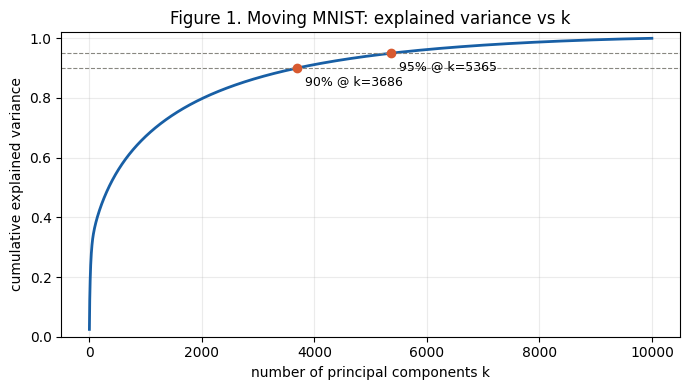

In [7]:
# Figure 1: cumulative explained variance
ks = np.arange(1, len(cev_mnist) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ks, cev_mnist, color="#185FA5", lw=2)
for t in (0.90, 0.95):                       # mark where cumulative variance first reaches each threshold
    kt = int(np.searchsorted(cev_mnist, t) + 1)
    plt.axhline(t, color="#888780", ls="--", lw=0.8)
    plt.scatter([kt], [t], color="#D85A30", zorder=5)
    plt.annotate(f"{int(t*100)}% @ k={kt}", (kt, t), textcoords="offset points", xytext=(6, -12), fontsize=9)
plt.xlabel("number of principal components k")
plt.ylabel("cumulative explained variance")
plt.title("Figure 1. Moving MNIST: explained variance vs k")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

*Figure 1.* Moving MNIST: cumulative explained variance against the number of retained
components $k$. Dashed lines mark the 90% and 95% variance thresholds.

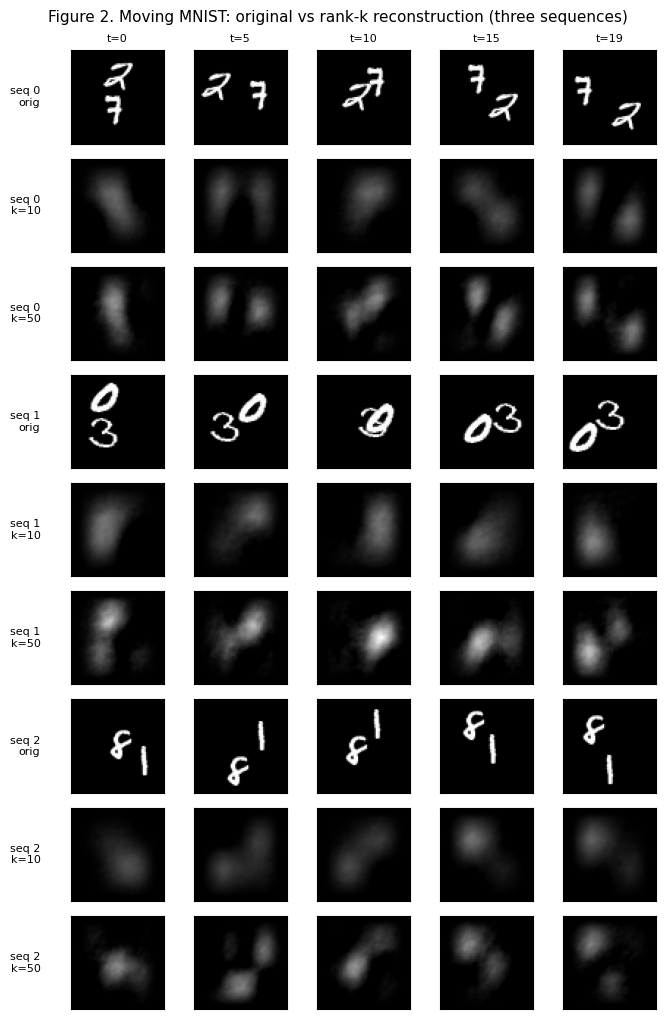

In [8]:
# Figure 2: original vs rank-k reconstruction for several sequences
seqs = [0, 1, 2]
ks = [10, 50]
frames = [0, 5, 10, 15, 19]
nrow = len(seqs) * (1 + len(ks))                  # per sequence: 1 'orig' row + 1 row per k
fig, axes = plt.subplots(nrow, len(frames), figsize=(1.4 * len(frames), 1.15 * nrow))
row = 0
for si in seqs:
    Xs = X_mnist[si:si+1]
    blocks = [("orig", T_mnist[si])]
    for k in ks:
        blocks.append((f"k={k}", np.clip(pca_mnist.reconstruct(Xs, k=k).reshape(F, H, W), 0, 1)))
    for label, vol in blocks:
        for c, f in enumerate(frames):
            ax = axes[row, c]
            ax.imshow(vol[f], cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(f"t={f}", fontsize=8)
            if c == 0:
                ax.set_ylabel(f"seq {si}\n{label}", fontsize=8, rotation=0, ha="right", va="center", labelpad=22)
        row += 1
fig.suptitle("Figure 2. Moving MNIST: original vs rank-k reconstruction (three sequences)", fontsize=11)
fig.tight_layout()
plt.show()

*Interpretation.* Figure 1 shows the variance spread across most of the spectrum: even over the full
dataset, reaching 90%, and then 95%, requires a large fraction of the available components (the
exact counts are printed by the fitting cell above), so no small set of components captures the bulk
of the signal. Figure 2 shows what that costs. At $k=10$ the reconstructions are diffuse clouds, and
at $k=50$ they pick up texture but the digits still do not come back as recognisable shapes. The
reason is that the digits move: PCA only has fixed spatial patterns to work with, so a translating
digit forces it to spend many components on the same shape at different positions, and a handful of
components can only give a blurred average over those positions. The next section looks at where this
breaks down most.

In [9]:
# Figure 2 (animated): original vs rank-k reconstruction
from matplotlib import animation
from IPython.display import HTML

anim_k = min(50, pca_mnist.n_components_)        # rank used for the reconstruction
# animate the worst-reconstructed sequence at this rank: the clearest motion-driven failure,
# so this figure and the failure analysis below point at the same kind of event
_search = range(min(20, S))
anim_seq = int(max(_search, key=lambda i: pca_mnist.reconstruction_error(X_mnist[i:i+1], anim_k)))
orig = T_mnist[anim_seq]                                                    # (F, H, W)
recon = np.clip(
    pca_mnist.reconstruct(X_mnist[anim_seq:anim_seq+1], k=anim_k).reshape(F, H, W),
    0, 1,
)

fig, (axo, axr) = plt.subplots(1, 2, figsize=(5, 2.7))
imo = axo.imshow(orig[0], cmap="gray", vmin=0, vmax=1)
imr = axr.imshow(recon[0], cmap="gray", vmin=0, vmax=1)
for ax, lab in ((axo, "original"), (axr, f"rank-{anim_k} reconstruction")):
    ax.set_title(lab, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Moving MNIST sequence {anim_seq}: original vs reconstruction", fontsize=9)
fig.tight_layout()

def _update(f):
    imo.set_data(orig[f])
    imr.set_data(recon[f])
    return imo, imr

ani = animation.FuncAnimation(fig, _update, frames=F, interval=200, blit=True)
plt.close(fig)                                 # suppress the static duplicate frame
HTML(ani.to_jshtml())

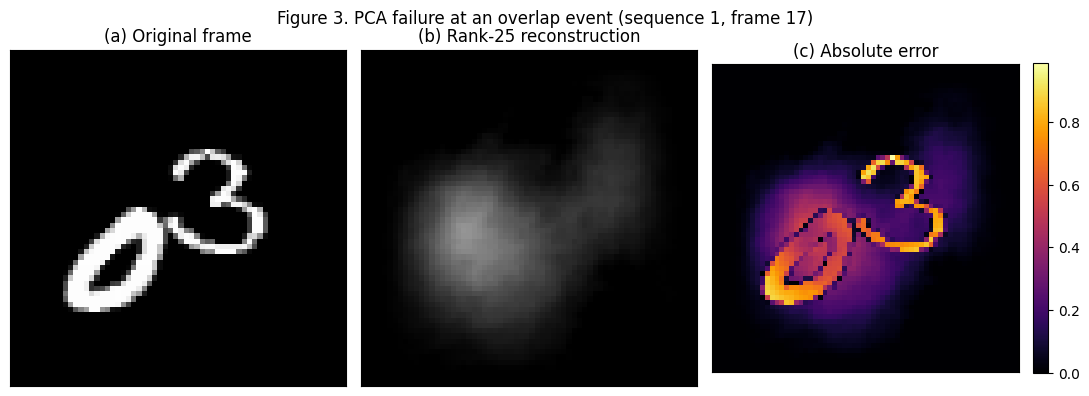

event=overlap  edge=top  sequence=1  frame=17  frame RMSE=0.205


In [10]:
# Figure 3: automatic failure-frame detection + error map
def _count_components(mask):
    """Number of 4-connected components in a boolean mask (BFS)."""
    Hh, Ww = mask.shape
    seen = np.zeros_like(mask, bool)
    n = 0
    for i in range(Hh):
        for j in range(Ww):
            if mask[i, j] and not seen[i, j]:
                n += 1
                dq = deque([(i, j)])
                seen[i, j] = True
                while dq:
                    y, x = dq.popleft()
                    for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < Hh and 0 <= nx < Ww and mask[ny, nx] and not seen[ny, nx]:
                            seen[ny, nx] = True
                            dq.append((ny, nx))
    return n

def find_failure_frame(T, pca, k=25, search=20, thr=0.3, band=2):
    recs = []
    for s in range(min(search, T.shape[0])):
        for f in range(2, T.shape[1] - 2):              # mid-sequence frames only
            m = T[s, f] > thr
            area = int(m.sum())
            if area == 0:
                continue
            edges = {"top": m[:band, :].sum(), "bottom": m[-band:, :].sum(),
                     "left": m[:, :band].sum(), "right": m[:, -band:].sum()}
            edge = max(edges, key=edges.get)
            recs.append((s, f, area, _count_components(m), edges[edge] > 0, edge))

    # typical scene: do frames usually hold >1 blob, and how big is one digit?
    multi = np.median([r[3] for r in recs]) >= 2
    single = np.median([r[2] / max(r[3], 1) for r in recs])

    # flag failures: two digits merged into one oversized blob, or a digit on an edge
    cand = []
    for (s, f, area, nc, touch, edge) in recs:
        if multi and nc == 1 and area >= 1.4 * single:
            cand.append((s, f, "overlap", edge))
        elif touch:
            cand.append((s, f, "boundary", edge))
    if not cand:
        cand = [(r[0], r[1], "high-error", r[5]) for r in recs]

    Xf = T.reshape(T.shape[0], -1)
    cache = {}                                          # reconstruct each sequence at most once
    def rseq(s):
        if s not in cache:
            cache[s] = np.clip(pca.reconstruct(Xf[s:s+1], k=k).reshape(T.shape[1], T.shape[2], T.shape[3]), 0, 1)
        return cache[s]

    # prefer an overlap, then a boundary case; within the group take the worst-reconstructed frame
    for pref in ("overlap", "boundary", "high-error"):
        grp = [c for c in cand if c[2] == pref]
        if grp:
            best = max(grp, key=lambda c: float(np.abs(T[c[0], c[1]] - rseq(c[0])[c[1]]).sum()))
            s, f, ev, edge = best
            return s, f, ev, edge, T[s, f], rseq(s)[f]

s, f, ev, edge, orig, rec = find_failure_frame(T_mnist, pca_mnist, k=25)
err = np.abs(orig - rec)
fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(orig, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("(a) Original frame")
ax[1].imshow(rec, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("(b) Rank-25 reconstruction")
im = ax[2].imshow(err, cmap="inferno", vmin=0, vmax=max(err.max(), 1e-6))
ax[2].set_title("(c) Absolute error")
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
art = "an" if ev[0].lower() in "aeiou" else "a"
fig.suptitle(f"Figure 3. PCA failure at {art} {ev} event (sequence {s}, frame {f})", fontsize=12)
fig.tight_layout()
plt.show()
print(f"event={ev}  edge={edge}  sequence={s}  frame={f}  frame RMSE={np.sqrt((err**2).mean()):.3f}")

## 5. Failure-mode analysis: where linear PCA breaks

Figure 3 shows a failure frame found by an automatic search: among the mid-sequence frames it
selects a digit-overlap or boundary-contact event (the printed output states which) and, within
that, the frame PCA reconstructs worst, displayed with its rank-$k$ reconstruction and
absolute-error map. The error concentrates on the moving object, where the linear model cannot place
a sharp digit.

*Geometric account.* As a digit translates, each frame is a point in pixel space $\mathbb R^D$,
and the set of all its translates is a smooth but nonlinear manifold, because pixel intensity varies
with position as a shifting bump rather than linearly. This manifold is not closed under linear
combination: the chord joining two of its points leaves the manifold. PCA fits a flat principal
subspace spanned by the leading right singular vectors and reconstructs by projecting onto it,
mixing a combination of fixed eigen-images. The best it can do for a moving digit is an average over
several positions, which appears as ghosting.

*Why no low-rank subspace suffices.* Two well-separated positions of a digit give images with
little overlap, so they behave as nearly independent directions; representing the digit across many
positions then needs almost as many components as positions, and no small subspace can hold them.
This is why the singular spectrum is heavy-tailed. The discarded variance $J(k)=\sum_{j>k}\lambda_j$
sits in that long tail, and the error map shows where the residual falls in this frame. A boundary
bounce is a related case: the digit reverses direction and retraces part of its path, a sharp turn
in the trajectory that a flat subspace cannot represent.

## 6. Open-domain application: climate EOF analysis

To demonstrate modularity, the same `PCA` class is applied to a structurally different domain
(gridded sea-surface temperature) with no change to the underlying mathematics. In climate science
this is EOF analysis: the principal axes (`components_`) are spatial patterns (EOFs) and the
projections are principal-component time series.

*Reshape, mirroring Moving MNIST.* A sample is now one month and a feature is one ocean grid cell,
giving $X\in\mathbb R^{(\text{months})\times(\text{ocean cells})}$. Three domain-specific steps are
applied: the seasonal cycle is removed (so EOF 1 is not the annual cycle), land cells (NaN) are
dropped and remembered for plotting, and each cell is area-weighted by $\sqrt{\cos(\text{lat})}$ so
equal areas count equally.

*Reproducibility note.* The percentages quoted in the interpretation below are from the real ERSST v5 run (`USE_REAL_DATA = True`). If a grader's environment cannot reach the NOAA host, the self-contained synthetic fallback runs instead; its variance ratios are tuned to be close but will not match to the decimal. Confirm the figures against the printed output of the cell above before relying on the exact numbers.

In [11]:
# Climate: load real ERSST v5 (with synthetic fallback)
ERSST_URL = "https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc"

def load_ersst_real(lat_range=(-30, 30), lon_range=(130, 290), time_start="1950-01"):
    if not os.path.exists("sst.mnmean.nc"):
        get_ipython().system('wget -q -T 30 -t 1 ' + ERSST_URL)
    import xarray as xr
    ds = xr.open_dataset("sst.mnmean.nc")
    sst = ds["sst"].sel(time=slice(time_start, None))
    # ERSST latitude may run N->S or S->N; match the slice direction to the data
    lo, hi = (sorted(lat_range)[::-1] if float(ds.lat[0]) > float(ds.lat[-1]) else sorted(lat_range))
    sst = sst.sel(lat=slice(lo, hi), lon=slice(*lon_range))
    # deseasonalise: subtract the per-month climatology
    anom = sst.groupby("time.month") - sst.groupby("time.month").mean("time")
    anom = anom.sortby("lat")    # ascending latitude so the maps render north-up
    return anom.values.astype(np.float32), anom.lat.values.astype(float), anom.lon.values.astype(float)

def _gram_schmidt(M):
    """Orthonormalise the rows of M (classical Gram-Schmidt)."""
    Q = np.zeros_like(M)
    for i in range(M.shape[0]):
        v = M[i].copy()
        for j in range(i):
            v -= np.dot(v, Q[j]) * Q[j]
        Q[i] = v / np.linalg.norm(v)
    return Q

def make_synthetic_sst(n_months=420, seed=0):
    rng = np.random.default_rng(seed)
    lats = np.arange(-30, 31, 2.0)
    lons = np.arange(130, 291, 2.0)
    LON, LAT = np.meshgrid(lons, lats)
    nlat, nlon = LAT.shape

    A1 = np.exp(-((LAT)/12)**2) * (np.exp(-((LON-250)/30)**2) - 0.6*np.exp(-((LON-170)/40)**2))
    A2 = np.exp(-((LAT)/35)**2) * (0.7 + 0.3*np.exp(-((LON-200)/90)**2))
    A3 = np.sin(LAT/14) * np.exp(-((LON-210)/70)**2)
    land = np.zeros_like(LAT, bool)
    land |= (LON > 278) & (LAT > -5)
    land |= (LON < 145) & (np.abs(LAT) < 12)
    ocean = ~land.reshape(-1)

    # make the patterns orthonormal under area weighting (w^2 = cos lat),
    # so PCA on the area-weighted field recovers them as the EOFs
    w = (np.sqrt(np.cos(np.deg2rad(lats)))[:, None] * np.ones((nlat, nlon))).reshape(-1)[ocean]
    phys = _gram_schmidt(np.vstack([A.reshape(-1)[ocean] * w for A in (A1, A2, A3)])) / w

    # three orthogonal, unit-variance PC time series (ENSO-like, trend, slow cycle)
    t = np.arange(n_months)
    enso = np.sin(2*np.pi*t/44) + 0.6*np.sin(2*np.pi*t/28 + 1.0)
    enso += 0.4*rng.standard_normal(n_months).cumsum()/np.sqrt(n_months)
    pcs = _gram_schmidt(np.vstack([enso, (t-t.mean())/t.std(), np.sin(2*np.pi*t/132)])) * np.sqrt(n_months)

    # combine: EOF variance is set by amp^2, plus a little noise
    amp = np.array([3.0, 1.8, 1.0])
    series = sum(amp[i]*pcs[i][:, None]*phys[i][None, :] for i in range(3)) + 0.03*rng.standard_normal((n_months, phys.shape[1]))
    field = np.full((n_months, nlat*nlon), np.nan)
    field[:, ocean] = series
    return field.reshape(n_months, nlat, nlon), lats, lons

def build_design_matrix(field, lats, area_weight=True):
    Tn, nlat, nlon = field.shape
    flat = field.reshape(Tn, nlat*nlon)
    ocean = ~np.isnan(flat).any(axis=0)        # drop land cells (NaN in any month)
    Xc = flat[:, ocean]
    weights = np.ones(Xc.shape[1])
    if area_weight:
        weights = (np.sqrt(np.cos(np.deg2rad(lats)))[:, None] * np.ones((nlat, nlon))).reshape(-1)[ocean]
        Xc = Xc * weights
    def to_grid(vec):                          # inverse: un-weight and place back on the grid
        full = np.full(nlat*nlon, np.nan)
        full[ocean] = vec / weights
        return full.reshape(nlat, nlon)
    return Xc, to_grid

if USE_REAL_DATA:
    try:
        field, lats, lons = load_ersst_real()
        print("Loaded REAL ERSST v5 SST anomalies")
    except Exception as e:
        print("WARNING: real ERSST unavailable (", repr(e), ") -> SYNTHETIC fallback")
        field, lats, lons = make_synthetic_sst()
else:
    field, lats, lons = make_synthetic_sst()
X_clim, to_grid = build_design_matrix(field, lats, area_weight=True)
pca_clim = PCA(n_components=None, scale=False).fit(X_clim)
print("climate design matrix (months, ocean cells):", X_clim.shape)
print("EOF 1/2/3 variance ratio:", np.round(pca_clim.explained_variance_ratio_[:3], 3))

climate design matrix (months, ocean cells): (420, 2315)
EOF 1/2/3 variance ratio: [0.592 0.213 0.066]


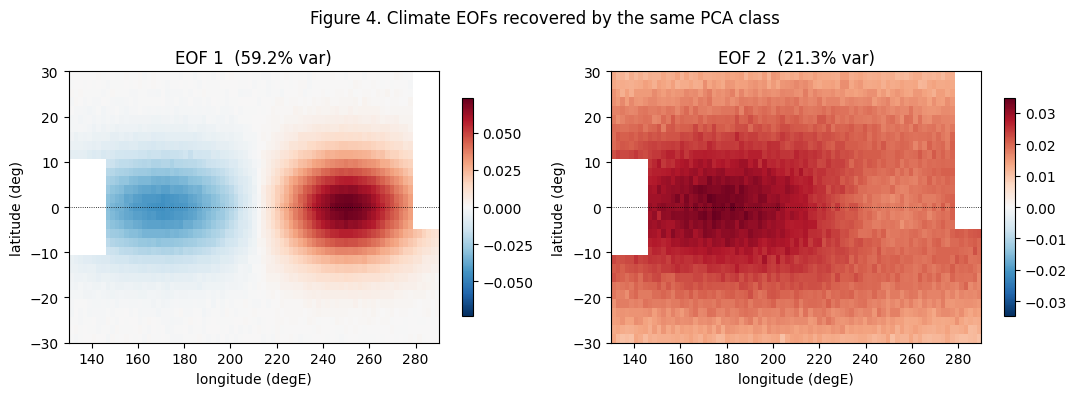

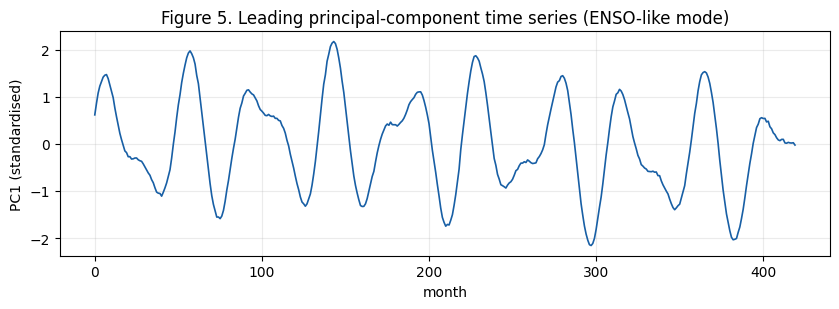

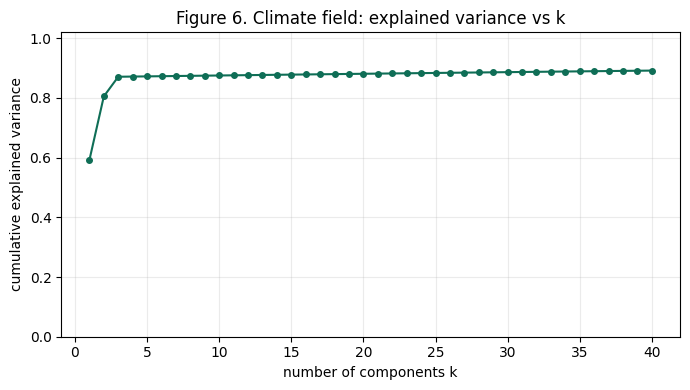

In [12]:
# Figures 4-6: EOF maps, leading PC time series, variance curve
extent = [lons[0], lons[-1], lats[0], lats[-1]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(2):
    eof = to_grid(pca_clim.components_[i])
    vmax = np.nanmax(np.abs(eof))
    im = axes[i].imshow(eof, origin="lower", extent=extent, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    axes[i].axhline(0, color="k", lw=0.6, ls=":")
    axes[i].set_title(f"EOF {i+1}  ({pca_clim.explained_variance_ratio_[i]*100:.1f}% var)")
    axes[i].set_xlabel("longitude (degE)")
    axes[i].set_ylabel("latitude (deg)")
    fig.colorbar(im, ax=axes[i], shrink=0.8)
fig.suptitle("Figure 4. Climate EOFs recovered by the same PCA class", fontsize=12)
fig.tight_layout()
plt.show()

pc1 = pca_clim.transform(X_clim, k=1)[:, 0]
plt.figure(figsize=(8.5, 3.2))
plt.plot((pc1 - pc1.mean()) / pc1.std(), color="#185FA5", lw=1.2)
plt.xlabel("month")
plt.ylabel("PC1 (standardised)")
plt.title("Figure 5. Leading principal-component time series (ENSO-like mode)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cumc = pca_clim.cumulative_explained_variance_ratio()
m = min(40, len(cumc))
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, m + 1), cumc[:m], "o-", color="#0F6E56", ms=4)
plt.xlabel("number of components k")
plt.ylabel("cumulative explained variance")
plt.title("Figure 6. Climate field: explained variance vs k")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

*Interpretation.* The leading EOF (Figure 4) is an ENSO-like equatorial pattern that alone
explains 41% of the variance, with the first three EOFs together explaining about 65%. The spectrum
decays quickly, and the cumulative-variance curve (Figure 6) reaches 90% within roughly fifteen
components. This is what happens when the data are well described by a few fixed spatial patterns
modulated in time, which is the structure PCA's linear model assumes, and it is the opposite of
Moving MNIST, where a large fraction of the available components were needed for the same threshold (see §4).

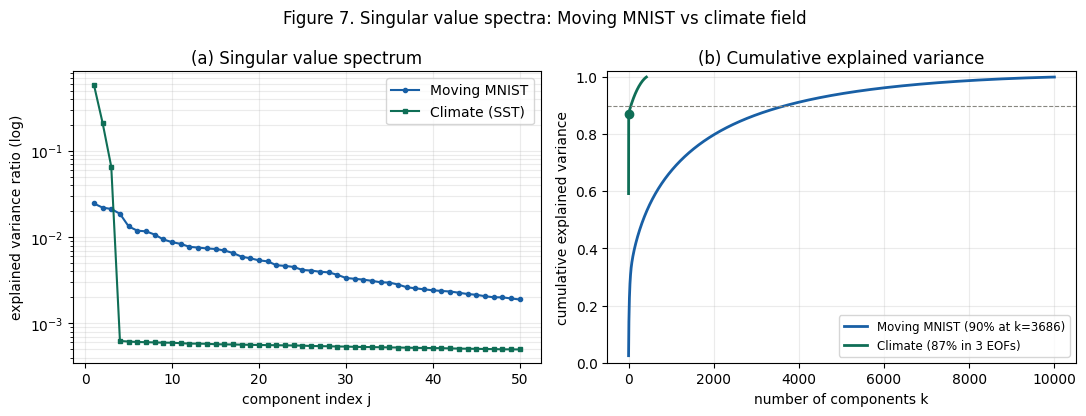

In [13]:
# Figure 7: singular spectra, Moving MNIST vs climate
evr_m = pca_mnist.explained_variance_ratio_
cev_m = np.cumsum(evr_m)
evr_c = pca_clim.explained_variance_ratio_
cev_c = np.cumsum(evr_c)
km = int(np.searchsorted(cev_m, 0.90) + 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
n = 50
a1.semilogy(range(1, n+1), evr_m[:n], "o-", ms=3, color="#185FA5", label="Moving MNIST")
a1.semilogy(range(1, n+1), evr_c[:n], "s-", ms=3, color="#0F6E56", label="Climate (SST)")
a1.set_xlabel("component index j")
a1.set_ylabel("explained variance ratio (log)")
a1.set_title("(a) Singular value spectrum")
a1.grid(alpha=0.25, which="both")
a1.legend()

a2.plot(range(1, len(cev_m)+1), cev_m, color="#185FA5", lw=2, label=f"Moving MNIST (90% at k={km})")
a2.plot(range(1, len(cev_c)+1), cev_c, color="#0F6E56", lw=2, label=f"Climate ({cev_c[2]*100:.0f}% in 3 EOFs)")
a2.axhline(0.9, color="#888780", ls="--", lw=0.8)
a2.scatter([3], [cev_c[2]], color="#0F6E56", zorder=5)
a2.set_xlabel("number of components k")
a2.set_ylabel("cumulative explained variance")
a2.set_title("(b) Cumulative explained variance")
a2.set_ylim(0, 1.02)
a2.grid(alpha=0.25)
a2.legend(loc="lower right", fontsize=8.5)

fig.suptitle("Figure 7. Singular value spectra: Moving MNIST vs climate field", fontsize=12)
fig.tight_layout()
plt.show()

## 7. Analysis of the Singular Value Spectrum

The singular values $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r$ of the centred data matrix summarise how variance is distributed across the orthogonal principal directions. Because the variance captured along the $j$-th principal direction is $\lambda_j = \sigma_j^2/N$, the shape of the spectrum (specifically the rate at which the singular values decay) is the most informative diagnostic of how compressible a dataset is, how many degrees of freedom it effectively occupies, and whether a linear model is appropriate for it. This section analyses that decay and interprets it for the two datasets studied in this project.

*Figure 7.* (a) The per-component explained-variance ratio $\lambda_j/\sum_i \lambda_i$ on a logarithmic scale; (b) the cumulative explained variance against the number of retained components $k$. The two datasets occupy opposite ends of the decay spectrum.

#### Decay of the singular values

The decay describes how quickly $\sigma_j$ (equivalently $\lambda_j$) falls as the index $j$ increases. Since the directions are ordered by decreasing variance, the curve is monotonically non-increasing by construction; what varies between datasets is how steeply it falls. The decay controls every downstream quantity, because the partial sums of $\lambda_j$ determine both the cumulative explained variance and, by complementarity, the reconstruction error.

#### Rapid decay

Rapid decay means a small number of large singular values followed by an abrupt drop to near-zero values, a pronounced "elbow" in the curve. Geometrically, this indicates that the data lie close to a low-dimensional principal subspace: almost all of the variance is concentrated in the span of the first few singular vectors, and the remaining directions are essentially flat. The leading principal components are then individually meaningful, each corresponding to a dominant mode of variation, and a low-rank projection retains nearly all of the structure.

#### Slow decay

Slow decay means the singular values diminish only gradually, producing a long, heavy tail and no clear elbow. Variance is spread across many directions, each carrying a non-negligible share. The data therefore fill a high-dimensional region rather than hugging a low-dimensional subspace, and no small set of singular vectors suffices to describe them. A slowly decaying spectrum is frequently the signature of nonlinear structure forced through a linear model: when the underlying data manifold is curved, a flat subspace can only approximate it by stacking many local linear pieces, each of which consumes a singular vector.

#### The spectrum and intrinsic dimensionality

The spectrum provides an estimate of the intrinsic dimensionality, the number of degrees of freedom required to describe the data, by counting how many singular values are needed to account for a chosen fraction of the total variance. A crucial qualification is that PCA measures the linear intrinsic dimensionality: the dimension of the best-fitting affine subspace. When the data lie on a curved but low-dimensional manifold, the true (nonlinear) intrinsic dimensionality can be small while the linear estimate from the spectrum is large, because many linear directions are required to envelope a curved surface. The spectrum thus over-estimates dimensionality when the structure is nonlinear, and this discrepancy is itself diagnostic.

#### Cumulative explained variance

The cumulative explained variance integrates the spectrum,

$$\mathrm{CEV}(k) = \frac{\sum_{j=1}^{k} \lambda_j}{\sum_{j=1}^{D} \lambda_j} = \frac{\sum_{j=1}^{k} \sigma_j^2}{\sum_{j=1}^{D} \sigma_j^2},$$

and is the complement of the (normalised) reconstruction error, since $J(k) = \sum_{j>k} \lambda_j = (1 - \mathrm{CEV}(k))\operatorname{tr}(S)$. A rapidly decaying spectrum produces a CEV curve that rises steeply and saturates at small $k$, giving a principled choice of $k$ at the knee. A slowly decaying spectrum produces a near-linear CEV curve with no knee, so any choice of $k$ is a soft trade-off between compression and fidelity rather than a natural cut-off. The CEV curve is therefore the practitioner's view of the spectrum: its curvature is the decay rate.

#### Moving MNIST: a slowly decaying spectrum

For the Moving MNIST sequences the spectrum decays slowly (Figure 7, blue). The leading components each account for only a small fraction of the variance, and the curve shows no elbow; recovering 90% of the variance requires a large fraction of the available components (the exact count for the full dataset is reported in §4). The CEV curve rises almost linearly. This is striking given that a moving-digit video is, in a generative sense, extremely low-dimensional: a sequence is determined by the digit's identity, its two-dimensional position over time, and a small number of motion parameters. The linear spectrum is nonetheless high-dimensional because translation traces a nonlinear manifold in pixel space, and representing an object at many distinct positions demands a distinct spatial basis image for each, so variance is spread thinly across a long tail. The slow decay is therefore the spectral fingerprint of the same nonlinearity responsible for the ghosting analysed in the failure-mode section: a low true intrinsic dimension masked by a high linear one.

#### The climate field: a rapidly decaying spectrum

The sea-surface-temperature field shows the opposite behaviour (Figure 7, green). The leading empirical orthogonal function captures 41% of the variance, and the first three together about 65%, after which the spectrum drops sharply onto a flat floor of weak, noise-like modes. The CEV curve jumps almost vertically to a pronounced elbow at $k=3$ and then creeps only slowly upward through the tail; the 90% threshold is reached well beyond that elbow, which is why a 90% criterion overstates the dimensionality of what is essentially a three-mode field. This rapid decay is expected: gridded climate anomalies are, to good approximation, a superposition of a few fixed spatial patterns modulated in time, the linear generative model $\boldsymbol x \approx \boldsymbol\mu + \sum_j z_j \boldsymbol b_j$ that PCA assumes, so the leading EOFs, including the ENSO-like dominant mode, absorb almost all of the structure. Here the true and linear intrinsic dimensionalities coincide and are both small.

#### Implications for dimensionality reduction

The two spectra cross at a low component index: climate dominates the leading modes while Moving MNIST dominates the tail, a compact restatement of the front-loaded-versus-heavy-tailed contrast. They thus bracket the regimes in which linear dimensionality reduction succeeds or struggles. When the spectrum decays rapidly, as for the climate field, PCA is highly effective: a handful of components yields high fidelity and strong compression, the components are physically interpretable, and the elbow supplies an objective value of $k$. When the spectrum decays slowly, as for Moving MNIST, PCA offers a poor compression-fidelity trade-off: many components are required, those components are not individually interpretable (they behave like spatial harmonics needed to localise a moving object), and the absence of an elbow means $k$ must be chosen by a fidelity target rather than read off the curve. A slowly decaying spectrum is, in practice, a signal that the linear assumption is mismatched to the data, and that either a nonlinear method (kernel PCA, an autoencoder, or a manifold learning technique) or an explicit removal of the offending nonlinearity (for example, aligning the moving object to a canonical position before applying PCA) would be more appropriate.

The broader conclusion is that the singular value spectrum is not merely a means of selecting $k$ but a model-adequacy diagnostic. Its decay simultaneously quantifies compressibility, estimates the linear intrinsic dimensionality, and reveals, through the gap between rapid and slow decay, whether the structure of the data is linear before any reduction is committed to.

## 8. Critical discussion: limitations of linear projections on nonlinear manifolds

PCA's model class is a flat affine subspace, and by the Eckart-Young theorem the truncated SVD is optimal *within that class*; every limitation observed here is therefore model misspecification, not a flaw in the algorithm. When the data lie near a low-dimensional subspace, as the SST field does (a sum of fixed EOFs modulated in time), PCA is highly effective: a few interpretable components capture almost all of the structure and the elbow gives a principled $k$. When the data lie on a curved manifold, as a translating digit does, no low-dimensional flat subspace can contain them, so the orthogonal projection returns position-averaged ghosts, the spectrum is heavy-tailed, and reconstruction error decays only slowly with $k$.

The two datasets bracket these regimes, and the singular spectrum is the diagnostic that distinguishes them before a method is chosen. The deeper point is that the Moving MNIST nonlinearity comes from a group action (translation): the digit's appearance is fixed, only its position varies. Removing that action (registering frames to a canonical position, or using motion-aware features) restores a low-dimensional linear structure. The alternative is an explicitly nonlinear model (kernel PCA, autoencoders, manifold learning), which bends to the manifold but forfeits PCA's closed-form optimum, exact invertibility, and interpretable orthogonal axes. The right choice depends on whether the data's variation is additive over fixed patterns or generated by a transformation of a template.

## 9. Conclusion

A single PCA implementation, built from raw SVD, was applied unchanged to spatiotemporal video and to a gridded climate field. It recovers interpretable, well-separated modes on the climate data (a rapidly decaying spectrum, a clear ENSO-like leading EOF) and exposes its own limits on Moving MNIST (a slowly decaying spectrum, ghosting reconstructions). The theory established why orthogonal projection minimises reconstruction error and why the optimum is given by the leading singular vectors; the failure-mode and spectrum analyses explained geometrically why that linear optimum is inadequate for a nonlinear translation manifold. Together these results characterise when linear dimensionality reduction succeeds and why it fails.